In [1]:
from samana.Data.j0607 import J0607_HSTF160W
from samana.Model.j0607_model import J0607ModelEPLM1M3M4ShearHST
import numpy as np
import matplotlib.pyplot as plt
from lenstronomy.Workflow.fitting_sequence import FittingSequence
import h5py

In [7]:
data = J0607_HSTF160W(use_noise_map=False)
data.mask_quasar_image_for_reconstruction(False)
model = J0607ModelEPLM1M3M4ShearHST(data, shapelets_order=10)
kwargs_lens_macro_init = None

kwargs_model, _, _, _, _, _ = model.setup_kwargs_model(kwargs_lens_macro_init=kwargs_lens_macro_init)
kwargs_params = model.kwargs_params(kwargs_lens_macro_init=kwargs_lens_macro_init)
kwargs_likelihood = model.kwargs_likelihood
kwargs_likelihood['prior_lens'] = [[0, 'gamma', 2.1, 0.05]]
fitting_sequence = FittingSequence(data.kwargs_data_joint, kwargs_model, model.kwargs_constraints, 
                                  kwargs_likelihood, kwargs_params)

nthreads = 10
psf_symmetry = 4
fitting_kwargs_list = [
        ['update_settings', {'lens_add_fixed': [[0, ['a3_a','a1_a'], [0.0,0.0]]]}],
        ['PSO', {'sigma_scale': 1., 'n_particles': 50, 'n_iterations': 400, 'threadCount': nthreads}],
        #['psf_iteration', {'psf_symmetry': psf_symmetry, 'keep_psf_variance_map': True, 'num_iter': 25}],
        #['MCMC', {'n_burn': 500, 'n_run': 1000, 'walkerRatio': 4, 'sigma_scale': 0.1, 'threadCount': nthreads}]
                          ]
chain_list = fitting_sequence.fit_sequence(fitting_kwargs_list)
kwargs_result = fitting_sequence.best_fit()

/Users/danielgilman/Code/external/lenstronomy/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(


Computing the PSO ...


  0%|                                                                                                                                                                                                                                       | 0/400 [00:00<?, ?it/s]/Users/danielgilman/Code/external/lenstronomy/lenstronomy/LensModel/Solver/solver4point.py:118: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  x = scipy.optimize.fsolve(
/Users/danielgilman/Code/external/lenstronomy/lenstronomy/LensModel/Solver/solver4point.py:118: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  x = scipy.optimize.fsolve(
/Users/danielgilman/Code/external/lenstronomy/lenstronomy/LensModel/Solver/solver4point.py:118: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluati

Max iteration reached! Stopping.
-1.9040871637485877 reduced X^2 of best position
-1103.4185113923065 log likelihood
1159 effective number of data points
[{'theta_E': np.float64(0.7787680314155474), 'gamma': np.float64(2.1790365676263663), 'e1': np.float64(-0.023566503623870732), 'e2': np.float64(0.07654396357946097), 'center_x': np.float64(-0.013824504900966168), 'center_y': np.float64(-0.00821092354722148), 'a1_a': 0.0, 'delta_phi_m1': np.float64(0.08221393638753163), 'a3_a': 0.0, 'delta_phi_m3': np.float64(-0.5127383171636161), 'a4_a': np.float64(-0.02651715557210645), 'delta_phi_m4': np.float64(-0.3413071913320564)}, {'gamma1': np.float64(-0.01602426662510929), 'gamma2': np.float64(-8.787862865963363e-05), 'ra_0': 0.0, 'dec_0': 0.0}, {'theta_E': np.float64(0.14866506976883265), 'center_x': np.float64(1.2285577490639825), 'center_y': np.float64(0.22300814724948034)}] lens result
[{'amp': 1, 'R_sersic': np.float64(0.1569936058855358), 'n_sersic': np.float64(4.830598205582899), 'e1': 

/Users/danielgilman/Code/external/lenstronomy/lenstronomy/Plots/model_band_plot.py:88: RuntimeWarning: divide by zero encountered in log10
  log_model = np.log10(model)
/Users/danielgilman/anaconda3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4608: RuntimeWarning: invalid value encountered in scalar subtract
  diff_b_a = b - a
/Users/danielgilman/Code/external/lenstronomy/lenstronomy/Plots/model_band_plot.py:309: RuntimeWarning: divide by zero encountered in log10
  np.log10(self._model),
/Users/danielgilman/Code/external/lenstronomy/lenstronomy/Plots/model_band_plot.py:916: RuntimeWarning: invalid value encountered in log10
  source_scale = np.log10(source)


-1.7102946960084657 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.7102946960087146
(31, ['gamma_lens0', 'delta_phi_m1_lens0', 'delta_phi_m3_lens0', 'a4_a_lens0', 'delta_phi_m4_lens0', 'gamma1_lens1', 'gamma2_lens1', 'theta_E_lens2', 'R_sersic_source_light0', 'n_sersic_source_light0', 'e1_source_light0', 'e2_source_light0', 'beta_source_light1', 'R_sersic_lens_light0', 'n_sersic_lens_light0', 'e1_lens_light0', 'e2_lens_light0', 'center_x_lens_light0', 'center_y_lens_light0', 'R_sersic_lens_light1', 'n_sersic_lens_light1', 'center_x_lens_light1', 'center_y_lens_light1', 'delta_x_image', 'delta_x_image', 'delta_x_image', 'delta_x_image', 'delta_y_image', 'delta_y_image', 'delta_y_image', 'delta_y_image'])


/Users/danielgilman/Code/external/lenstronomy/lenstronomy/Plots/model_band_plot.py:1445: RuntimeWarning: invalid value encountered in log10
  np.log10(model),


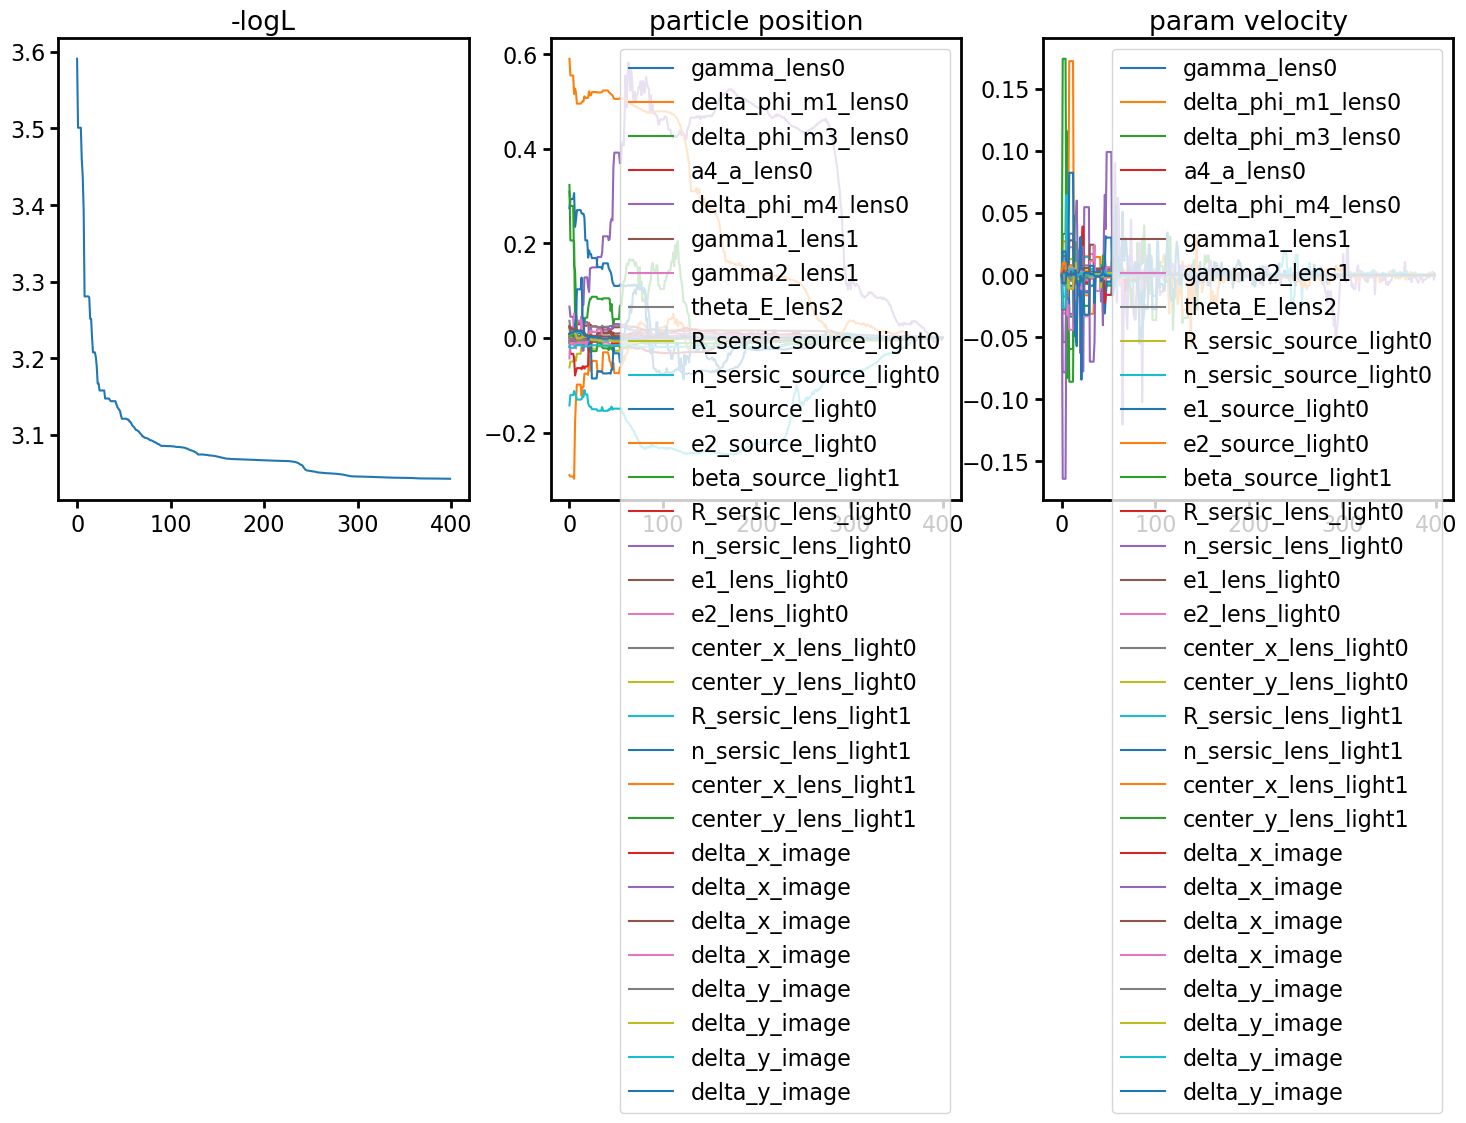

<Figure size 640x480 with 0 Axes>

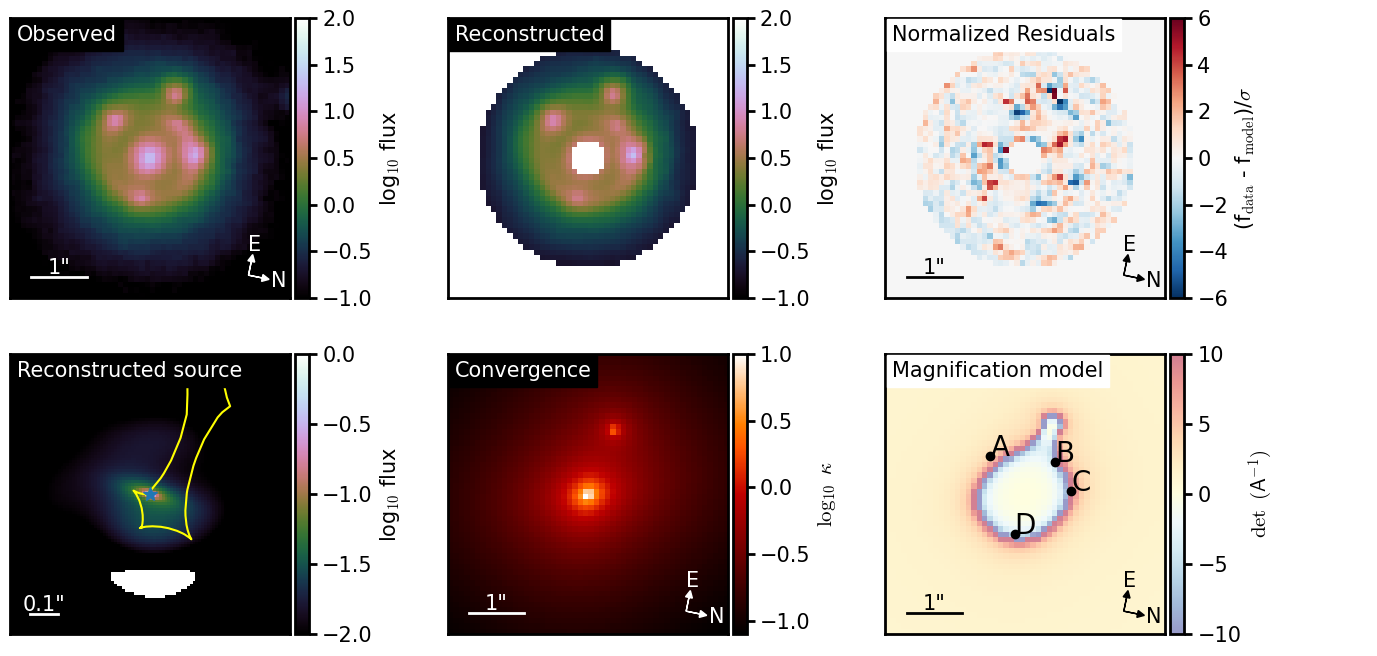

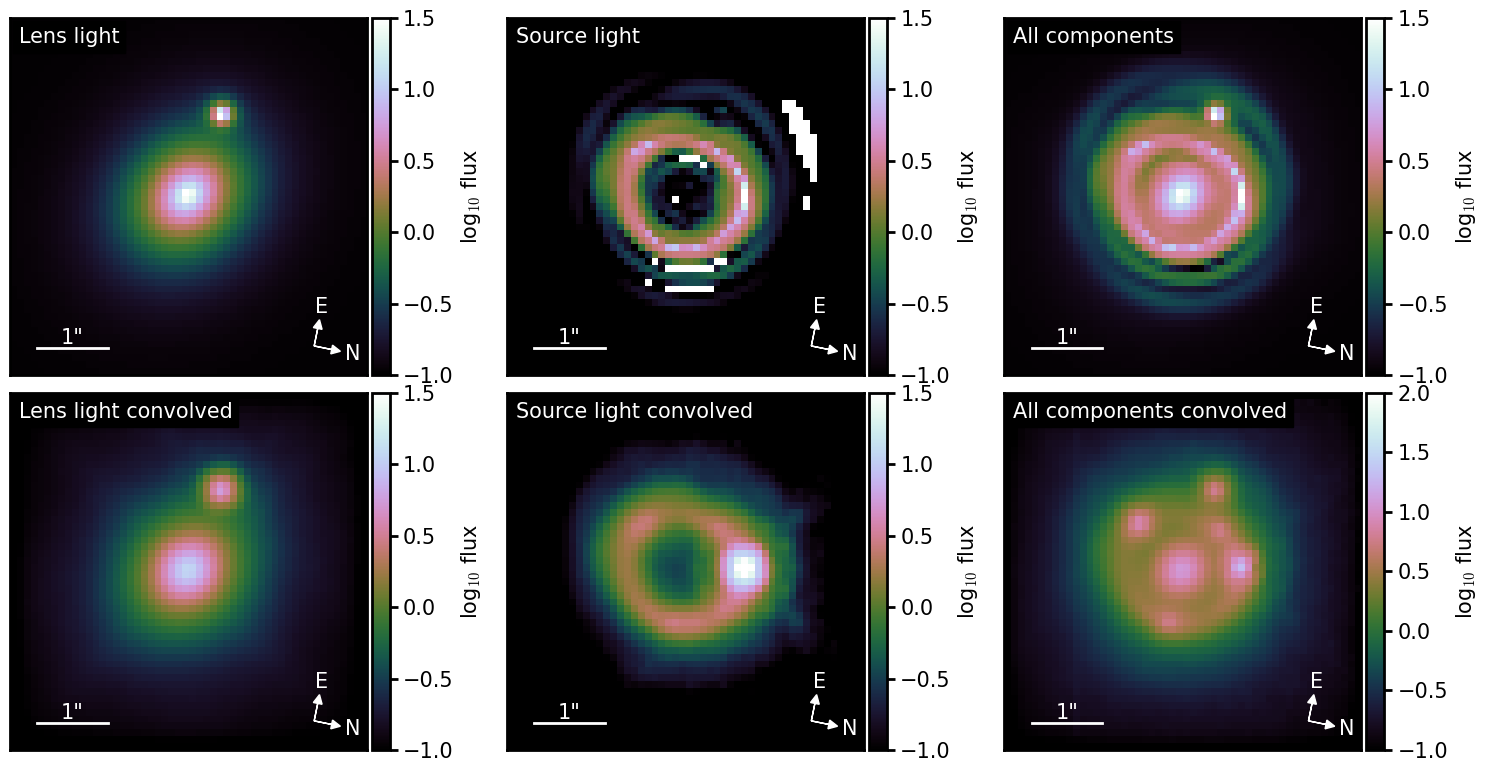

[{'theta_E': np.float64(0.7787680314155474), 'gamma': np.float64(2.1790365676263663), 'e1': np.float64(-0.023566503623870732), 'e2': np.float64(0.07654396357946097), 'center_x': np.float64(-0.013824504900966168), 'center_y': np.float64(-0.00821092354722148), 'a1_a': 0.0, 'delta_phi_m1': np.float64(0.08221393638753163), 'a3_a': 0.0, 'delta_phi_m3': np.float64(-0.5127383171636161), 'a4_a': np.float64(-0.02651715557210645), 'delta_phi_m4': np.float64(-0.3413071913320564)}, {'gamma1': np.float64(-0.01602426662510929), 'gamma2': np.float64(-8.787862865963363e-05), 'ra_0': 0.0, 'dec_0': 0.0}, {'theta_E': np.float64(0.14866506976883265), 'center_x': np.float64(1.2285577490639825), 'center_y': np.float64(0.22300814724948034)}]
[{'amp': np.float64(35.101188529717334), 'R_sersic': np.float64(0.1569936058855358), 'n_sersic': np.float64(4.830598205582899), 'e1': np.float64(-0.45869666519884916), 'e2': np.float64(-0.09469879944758845), 'center_x': np.float64(0.16615865252782308), 'center_y': np.flo

In [8]:
from lenstronomy.Plots.model_plot import ModelPlot
from lenstronomy.Plots import chain_plot
import matplotlib.pyplot as plt

multi_band_list = data.kwargs_data_joint['multi_band_list']
modelPlot = ModelPlot(multi_band_list, kwargs_model, kwargs_result,
                      image_likelihood_mask_list=[data.likelihood_mask],fast_caustic=True)

param_class = fitting_sequence.param_class
print(param_class.num_param())
#print(chain_list)

for i in range(len(chain_list)):
    chain_plot.plot_chain_list(chain_list, i)

f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)
modelPlot.data_plot(ax=axes[0, 0], vmin=-1, vmax=2)
modelPlot.model_plot(ax=axes[0, 1], vmin=-1, vmax=2)
modelPlot.normalized_residual_plot(ax=axes[0, 2], vmin=-6, vmax=6)
modelPlot.source_plot(ax=axes[1, 0], delta_pix_source=0.01, num_pix=100, vmin=-2, vmax=0)
modelPlot.convergence_plot(ax=axes[1, 1], vmax=1)
modelPlot.magnification_plot(ax=axes[1, 2])

f, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)
modelPlot.decomposition_plot(ax=axes[0, 0], kwargs_title={'text': 'Lens light'}, lens_light_add=True,
                             unconvolved=True, vmin=-1,vmax=1.5
                            )
modelPlot.decomposition_plot(ax=axes[1, 0], kwargs_title={'text': 'Lens light convolved'}, lens_light_add=True, 
                             vmin=-1,vmax=1.5)
modelPlot.decomposition_plot(ax=axes[0, 1], kwargs_title={'text': 'Source light'}, source_add=True,
                             unconvolved=True,  vmin=-1,vmax=1.5)
modelPlot.decomposition_plot(ax=axes[1, 1], kwargs_title={'text': 'Source light convolved'}, source_add=True, 
                             vmin=-1,vmax=1.5)
modelPlot.decomposition_plot(ax=axes[0, 2], kwargs_title={'text': 'All components'}, source_add=True,
                             lens_light_add=True,
                             unconvolved=True,  vmin=-1,vmax=1.5)
modelPlot.decomposition_plot(ax=axes[1, 2], kwargs_title={'text': 'All components convolved'}, source_add=True,
                             lens_light_add=True, point_source_add=True,
                             unconvolved=False,  vmin=-1,vmax=2)
f.tight_layout()
f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0., hspace=0.05)
plt.show()

print(kwargs_result['kwargs_lens'])
print(kwargs_result['kwargs_source'])
print(kwargs_result['kwargs_lens_light'])

/Users/danielgilman/Code/external/lenstronomy/lenstronomy/LensModel/MultiPlane/multi_plane.py:81: UserWarning: Cosmology is provided. Make sure your cosmological model is consistent with the cosmology_model argument.
  warnings.warn(
/Users/danielgilman/Code/external/lenstronomy/lenstronomy/Plots/model_band_plot.py:88: RuntimeWarning: divide by zero encountered in log10
  log_model = np.log10(model)
/Users/danielgilman/anaconda3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4608: RuntimeWarning: invalid value encountered in scalar subtract
  diff_b_a = b - a
/Users/danielgilman/Code/external/lenstronomy/lenstronomy/Plots/model_band_plot.py:309: RuntimeWarning: divide by zero encountered in log10
  np.log10(self._model),


-1.7102946960084657 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  1.7102946960087146


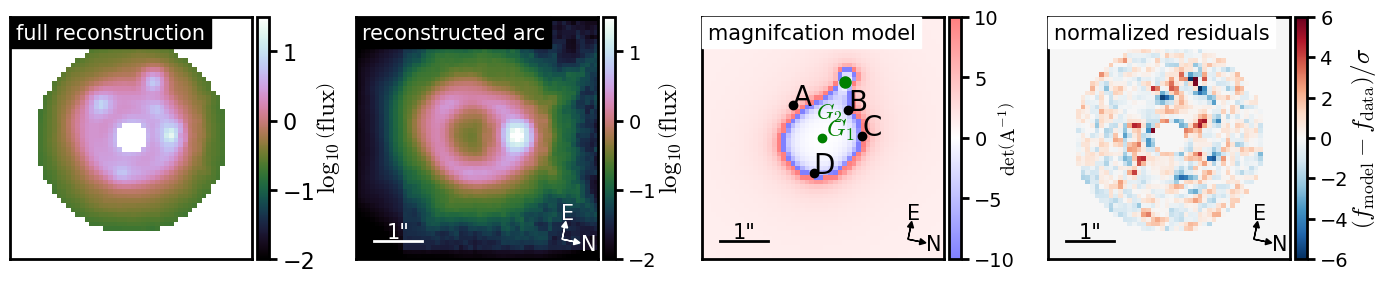

In [16]:
plt.rcParams['axes.linewidth'] = 2.
plt.rcParams['xtick.major.width'] = 2.
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['xtick.minor.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 3.5
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['ytick.minor.width'] = 1.0
plt.rcParams['ytick.minor.size'] = 3.5
plt.rcParams.update({'font.size': 16})
plt.rcParams['mathtext.fontset'] = 'cm'

modelPlot = ModelPlot(multi_band_list, kwargs_model, kwargs_result,
                      image_likelihood_mask_list=[data.likelihood_mask],fast_caustic=True)

fig = plt.figure(1)
fig.set_size_inches(14,4.5)

ax1 = plt.subplot(141)
modelPlot._arrow_size = 0
v_min = -2.
v_max = v_min + 3.5
modelPlot.model_plot(ax=ax1,
                    vmin=v_min,vmax=v_max, kwargs_title={'text': 'full reconstruction'},font_size=16)
im = ax1.images
cb = im[-1].colorbar 
cb.set_label(r'$\log_{10}\left(\rm{flux}\right)$',labelpad=0,fontsize=18)


ax2 = plt.subplot(142)
modelPlot._arrow_size = 0
modelPlot.decomposition_plot(ax=ax2, kwargs_title={'text': 'reconstructed arc'}, unconvolved=False, 
                             source_add=True, vmin=v_min, vmax=v_max,
                             font_size=14)
im = ax2.images
cb = im[-1].colorbar 
#cb.set_ticklabels(ticks,fontsize=16)
cb.set_label(r'$\log_{10}\left(\rm{flux}\right)$',labelpad=0,fontsize=18)

ax3 = plt.subplot(143)
modelPlot._arrow_size = 0
v_min = -3
v_max = v_min + 3.
modelPlot.magnification_plot(ax=ax3, cmap='bwr', kwargs_title={'text': 'magnifcation model'}, font_size=14)
im = ax3.images
cb = im[-1].colorbar 
cb.set_label(r'$\rm{det}\left(A^{-1}\right)$',labelpad=-12)

satx = kwargs_result['kwargs_lens'][0]['center_x']
saty = kwargs_result['kwargs_lens'][0]['center_y']
xplot, yplot = data.coordinate_system.map_coord2pix(satx, saty)
pixel_width = data.coordinate_system.pixel_width
origin = [0,0]
x_ = xplot * pixel_width + origin[0]
y_ = yplot * pixel_width + origin[1]
ax3.plot(x_, y_, ".", color='g',markersize=12,alpha=1.)
ax3.text(x_+0.08, y_+0.05, r'$G_1$', fontsize=18, color='g')

satx = kwargs_result['kwargs_lens'][2]['center_x']
saty = kwargs_result['kwargs_lens'][2]['center_y']
xplot, yplot = data.coordinate_system.map_coord2pix(satx, saty)
pixel_width = data.coordinate_system.pixel_width
origin = [0,0]
x_ = xplot * pixel_width + origin[0]
y_ = yplot * pixel_width + origin[1]
ax3.plot(x_, y_, ".", color='g',markersize=16,alpha=1.)
ax3.text(x_-0.6, y_-0.75, r'$G_2$', fontsize=16, color='g')


ax4 = plt.subplot(144)
modelPlot._arrow_size = 0
modelPlot.normalized_residual_plot(ax=ax4,
                    vmin=-6, vmax=6, cmap='RdBu_r',font_size=14, kwargs_title={'text': 'normalized residuals'})
im = ax4.images
cb = im[-1].colorbar 
cb.set_label(r'$\left(f_{\rm{model}}-f_{\rm{data}}\right)/\sigma$',labelpad=0,fontsize=18)

plt.subplots_adjust(wspace=-0.43, hspace=0.1)
plt.tight_layout()

plt.savefig('./0607bmodel_hst.pdf',bbox_inches='tight')

In [9]:
from lenstronomy.LightModel.light_model import LightModel

lm = LightModel(['SERSIC_ELLIPSE', 'SERSIC_ELLIPSE'])   # [deflector, satellite]
f_tot = lm.total_flux(kwargs_result['kwargs_lens_light'])                # analytic, per component
ratio = f_tot[1] / f_tot[0]
print(np.sqrt(ratio) * kwargs_result['kwargs_lens'][0]['theta_E'])

0.3434279685438293
